In [1]:
import polars as pl
import seaborn as sns
import numpy as np

import matplotlib.pyplot as plt

In [2]:
sns.set_theme(rc={"font.sans-serif": ["Ubuntu"]})
sns.set_context("paper")

In [3]:
LABELS = ["O",
"B-ENERGY_KJ_100G",
"I-ENERGY_KJ_100G",
"B-VITAMIN_D_SERVING",
"I-VITAMIN_D_SERVING",
"B-SODIUM_SERVING",
"I-SODIUM_SERVING",
"B-PROTEINS_SERVING",
"I-PROTEINS_SERVING",
"B-ADDED_SUGARS_SERVING",
"I-ADDED_SUGARS_SERVING",
"B-CALCIUM_SERVING",
"I-CALCIUM_SERVING",
"B-FAT_SERVING",
"I-FAT_SERVING",
"B-ENERGY_KJ_SERVING",
"I-ENERGY_KJ_SERVING",
"B-SUGARS_100G",
"I-SUGARS_100G",
"B-SATURATED_FAT_SERVING",
"I-SATURATED_FAT_SERVING",
"B-SERVING_SIZE",
"I-SERVING_SIZE",
"B-SALT_SERVING",
"I-SALT_SERVING",
"B-ENERGY_KCAL_SERVING",
"I-ENERGY_KCAL_SERVING",
"B-FAT_100G",
"I-FAT_100G",
"B-SUGARS_SERVING",
"I-SUGARS_SERVING",
"B-FIBER_SERVING",
"I-FIBER_SERVING",
"B-TRANS_FAT_SERVING",
"I-TRANS_FAT_SERVING",
"B-POTASSIUM_SERVING",
"I-POTASSIUM_SERVING",
"B-CARBOHYDRATES_100G",
"I-CARBOHYDRATES_100G",
"B-POTASSIUM_100G",
"I-POTASSIUM_100G",
"B-IRON_SERVING",
"I-IRON_SERVING",
"B-CHOLESTEROL_100G",
"I-CHOLESTEROL_100G",
"B-TRANS_FAT_100G",
"I-TRANS_FAT_100G",
"B-ADDED_SUGARS_100G",
"I-ADDED_SUGARS_100G",
"B-FIBER_100G",
"I-FIBER_100G",
"B-CALCIUM_100G",
"I-CALCIUM_100G",
"B-SODIUM_100G",
"I-SODIUM_100G",
"B-ENERGY_KCAL_100G",
"I-ENERGY_KCAL_100G",
"B-CHOLESTEROL_SERVING",
"I-CHOLESTEROL_SERVING",
"B-CARBOHYDRATES_SERVING",
"I-CARBOHYDRATES_SERVING",
"B-SALT_100G",
"I-SALT_100G",
"B-VITAMIN_D_100G",
"I-VITAMIN_D_100G",
"B-SATURATED_FAT_100G",
"I-SATURATED_FAT_100G",
"B-PROTEINS_100G",
"I-PROTEINS_100G",
"B-IRON_100G",
"I-IRON_100G"]

ID2LABEL = {}

for label_id, label_name in enumerate(LABELS):
    if label_name != "O":
        _, label_name = label_name.split("-", maxsplit=1)
    ID2LABEL[label_id] = label_name

In [4]:
df = pl.read_parquet("/home/raphael/Projects/hf-datasets/nutrient-detection-layout/data/*.parquet",
                     columns=["ner_tags", "tokens", "meta"])

In [5]:
df_by_ner_tags = df.explode("ner_tags").with_columns(ner_tag_string=pl.col("ner_tags").replace_strict(ID2LABEL).str.to_lowercase())

In [6]:
ner_tags_count = df_by_ner_tags["ner_tag_string"].value_counts().filter(pl.col("ner_tag_string") != "o").sort("count", descending=True)
ner_tags_count

ner_tag_string,count
str,u32
"""energy_kcal_100g""",5028
"""energy_kj_100g""",4710
"""fat_100g""",4517
"""carbohydrates_100g""",4511
"""salt_100g""",4453
…,…
"""vitamin_d_100g""",42
"""trans_fat_100g""",38
"""potassium_100g""",27


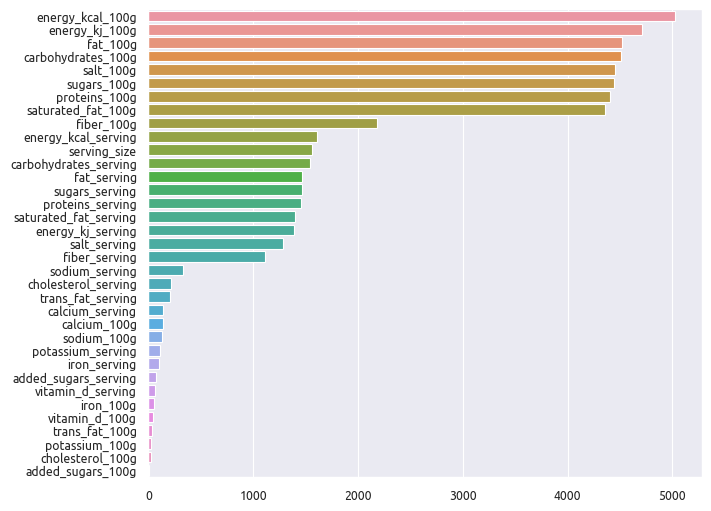

In [7]:
fig, ax = plt.subplots(figsize=(7, 5), layout="constrained")
sns.barplot(y=np.array(ner_tags_count["ner_tag_string"]), x=np.array(ner_tags_count["count"]), orient="h", ax=ax)
plt.savefig("/home/raphael/Projects/openfoodfacts-ai/nutrisight/analysis/label_count.png")

In [8]:
help(plt.subplots)

Help on function subplots in module matplotlib.pyplot:

subplots(nrows=1, ncols=1, *, sharex=False, sharey=False, squeeze=True, width_ratios=None, height_ratios=None, subplot_kw=None, gridspec_kw=None, **fig_kw)
    Create a figure and a set of subplots.
    
    This utility wrapper makes it convenient to create common layouts of
    subplots, including the enclosing figure object, in a single call.
    
    Parameters
    ----------
    nrows, ncols : int, default: 1
        Number of rows/columns of the subplot grid.
    
    sharex, sharey : bool or {'none', 'all', 'row', 'col'}, default: False
        Controls sharing of properties among x (*sharex*) or y (*sharey*)
        axes:
    
        - True or 'all': x- or y-axis will be shared among all subplots.
        - False or 'none': each subplot x- or y-axis will be independent.
        - 'row': each subplot row will share an x- or y-axis.
        - 'col': each subplot column will share an x- or y-axis.
    
        When subplots 

In [9]:
df_meta = df.select("meta").unnest("meta")

In [10]:
df_meta.columns

['barcode',
 'image_id',
 'image_url',
 'split',
 'ocr_url',
 'batch',
 'label_studio_id',
 'checked',
 'usda_table',
 'nutrition_text',
 'no_nutrition_table',
 'comment']

In [11]:
df_meta

barcode,image_id,image_url,split,ocr_url,batch,label_studio_id,checked,usda_table,nutrition_text,no_nutrition_table,comment
str,str,str,str,str,str,i64,bool,bool,bool,bool,str
"""3700821000223""","""2""","""https://images.openfoodfacts.o…","""test""","""https://images.openfoodfacts.o…","""batch-17""",20959,true,false,true,false,""""""
"""06174988""","""13""","""https://images.openfoodfacts.o…","""test""","""https://images.openfoodfacts.o…","""batch-35""",18422,true,false,false,false,""""""
"""7613379505774""","""2""","""https://images.openfoodfacts.o…","""test""","""https://images.openfoodfacts.o…","""batch-35""",19740,true,false,false,false,""""""
"""2642824003775""","""2""","""https://images.openfoodfacts.o…","""test""","""https://images.openfoodfacts.o…","""batch-34""",20657,true,false,false,false,""""""
"""3760038790034""","""2""","""https://images.openfoodfacts.o…","""test""","""https://images.openfoodfacts.o…","""batch-11""",18050,true,false,true,false,""""""
…,…,…,…,…,…,…,…,…,…,…,…
"""8000500329610""","""5""","""https://images.openfoodfacts.o…","""train""","""https://images.openfoodfacts.o…","""batch-26""",18624,true,false,true,false,""""""
"""3760281270369""","""2""","""https://images.openfoodfacts.o…","""train""","""https://images.openfoodfacts.o…","""batch-25""",20581,true,false,true,false,""""""
"""3442310001464""","""4""","""https://images.openfoodfacts.o…","""train""","""https://images.openfoodfacts.o…","""batch-27""",20144,true,false,true,false,""""""


In [12]:
usda_table_value_count = df_meta["usda_table"].value_counts()
usda_table_value_count

usda_table,count
bool,u32
true,140
false,2943


In [13]:
nutrition_text_value_count = df_meta["nutrition_text"].value_counts()
nutrition_text_value_count

nutrition_text,count
bool,u32
true,531
false,2552


<Axes: >

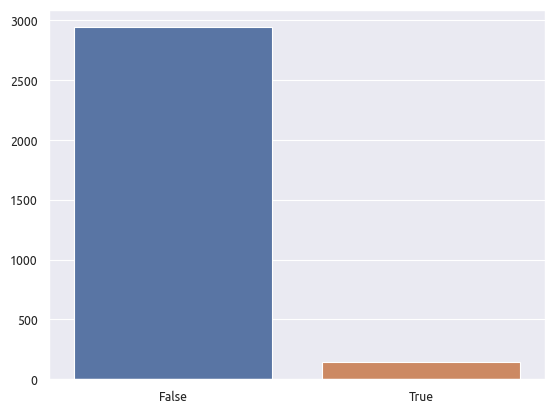

In [14]:
sns.barplot(y=np.array(usda_table_value_count["count"]), x=np.array(usda_table_value_count["usda_table"]), orient="v")

## Language

In [15]:
from openfoodfacts.ocr import OCRResult
from openfoodfacts.utils import http_session
from collections import defaultdict
import tqdm

def get_image_lang(ocr_result: OCRResult):
    image_lang: Optional[dict[str, int]] = ocr_result.get_languages()
    if image_lang is None:
        return None
    words = image_lang["words"]
    percents = {}
    for key, count in image_lang.items():
        if key == "words":
            continue
        percents[key] = count * 100 / words
    return percents

main_lang_all = defaultdict(int)
lang_all = defaultdict(int)

lang_threshold = 10
count = 0
for barcode, image_id, ocr_url in tqdm.tqdm(df_meta.select("barcode", "image_id", "ocr_url").iter_rows()):
    ocr_result = OCRResult.from_url(ocr_url)
    percents = get_image_lang(ocr_result)
    # print(percents)
    if percents is None:
        print(f"prediction for image {image_id} (code: {barcode}) not found")
    else:
        count += 1
        main_lang = max(percents.items(), key=lambda x: x[1])[0]
        main_lang_all[main_lang] += 1
        for lang, percent in percents.items():
            if percent >= lang_threshold:
                lang_all[lang] += 1

3083it [14:18,  3.59it/s]


In [24]:
for lang, c in sorted(main_lang_all.items(), key=lambda x: x[1], reverse=True):
    print(f"{lang}: {c} - {c * 100 / count}")

fr: 1098 - 35.614661044437234
en: 658 - 21.342847875445994
es: 485 - 15.731430424910801
de: 238 - 7.7197534868634445
nl: 212 - 6.876419072332144
it: 86 - 2.789490755757379
null: 85 - 2.7570548167369444
pt: 44 - 1.4271813168991243
pl: 31 - 1.0055141096334739
fi: 21 - 0.6811547194291274
ca: 19 - 0.6162828413882582
sl: 18 - 0.5838469023678236
sv: 12 - 0.3892312682452157
ar: 11 - 0.3567953292247811
hu: 9 - 0.2919234511839118
lt: 8 - 0.25948751216347715
ro: 8 - 0.25948751216347715
no: 6 - 0.19461563412260785
hr: 5 - 0.1621796951021732
el: 4 - 0.12974375608173858
sk: 4 - 0.12974375608173858
et: 3 - 0.09730781706130393
bs: 2 - 0.06487187804086929
zh: 2 - 0.06487187804086929
da: 2 - 0.06487187804086929
bg: 2 - 0.06487187804086929
cs: 1 - 0.032435939020434644
mk: 1 - 0.032435939020434644
sq: 1 - 0.032435939020434644
lb: 1 - 0.032435939020434644
ko: 1 - 0.032435939020434644
lv: 1 - 0.032435939020434644
th: 1 - 0.032435939020434644
ru-PETR1708: 1 - 0.032435939020434644
uk: 1 - 0.03243593902043464

In [25]:
for lang, c in sorted(lang_all.items(), key=lambda x: x[1], reverse=True):
    print(f"{lang}: {c} - {c * 100 / count}")

en: 2174 - 70.5157314304249
fr: 1710 - 55.46545572494324
null: 1622 - 52.61109309114499
es: 682 - 22.121310411936424
de: 575 - 18.65066493674992
nl: 384 - 12.455400583846902
pt: 358 - 11.612066169315602
it: 227 - 7.362958157638664
lb: 78 - 2.530003243593902
sv: 53 - 1.719104768083036
pl: 49 - 1.5893610120012975
sl: 34 - 1.1028219266947779
ca: 33 - 1.0703859876743431
fi: 29 - 0.9406422315926046
cs: 26 - 0.8433344145313006
ar: 24 - 0.7784625364904314
hr: 24 - 0.7784625364904314
hu: 23 - 0.7460265974699968
sk: 20 - 0.6487187804086928
no: 20 - 0.6487187804086928
da: 20 - 0.6487187804086928
ro: 16 - 0.5189750243269543
co: 15 - 0.4865390853065196
el: 12 - 0.3892312682452157
lt: 11 - 0.3567953292247811
lv: 11 - 0.3567953292247811
bg: 11 - 0.3567953292247811
et: 9 - 0.2919234511839118
la: 8 - 0.25948751216347715
id: 7 - 0.2270515731430425
gn: 7 - 0.2270515731430425
bs: 6 - 0.19461563412260785
gl: 6 - 0.19461563412260785
gd: 5 - 0.1621796951021732
ru-PETR1708: 4 - 0.12974375608173858
mk: 4 - 0.